<a href="https://colab.research.google.com/github/hamshini1413/deep-learning/blob/main/5_Custom_Batch_Normalization_and_Layer_Normalization_Forward_Backward_Propagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [2]:
X = torch.randn(128,10)

print("Input Shape :",X.shape)

Input Shape : torch.Size([128, 10])


In [3]:
class BatchNorm:

    def __init__(self,features,eps=1e-5,momentum=0.9):

        self.gamma=torch.ones(features)

        self.beta=torch.zeros(features)

        self.running_mean=torch.zeros(features)

        self.running_var=torch.ones(features)

        self.eps=eps

        self.momentum=momentum


    def forward(self,x):

        self.mean=x.mean(dim=0)

        self.var=x.var(dim=0,unbiased=False)

        self.x_hat=(x-self.mean)/torch.sqrt(self.var+self.eps)

        out=self.gamma*self.x_hat+self.beta

        self.running_mean=self.momentum*self.running_mean+(1-self.momentum)*self.mean

        self.running_var=self.momentum*self.running_var+(1-self.momentum)*self.var

        return out

In [4]:
class LayerNorm:

    def __init__(self,features,eps=1e-5):

        self.gamma=torch.ones(features)

        self.beta=torch.zeros(features)

        self.eps=eps


    def forward(self,x):

        self.mean=x.mean(dim=1,keepdim=True)

        self.var=x.var(dim=1,keepdim=True,unbiased=False)

        self.x_hat=(x-self.mean)/torch.sqrt(self.var+self.eps)

        out=self.gamma*self.x_hat+self.beta

        return out

In [5]:
def backward(x,x_hat,gamma,grad_output,var,eps):

    N=x.shape[0]

    dbeta=grad_output.sum(dim=0)

    dgamma=(grad_output*x_hat).sum(dim=0)

    dxhat=grad_output*gamma

    dvar=(-0.5*(dxhat*(x-x.mean(0))).sum(0))*((var+eps)**(-1.5))

    dmean=(-dxhat/torch.sqrt(var+eps)).sum(0)+dvar*(-2*(x-x.mean(0)).mean(0))

    dx=dxhat/torch.sqrt(var+eps)+dvar*2*(x-x.mean(0))/N+dmean/N

    return dx,dgamma,dbeta

In [6]:
bn=BatchNorm(10)

bn_output=bn.forward(X)

print("BatchNorm Output Shape")

print(bn_output.shape)

BatchNorm Output Shape
torch.Size([128, 10])


In [7]:
ln=LayerNorm(10)

ln_output=ln.forward(X)

print("LayerNorm Output Shape")

print(ln_output.shape)

LayerNorm Output Shape
torch.Size([128, 10])


In [8]:
grad=torch.ones_like(bn_output)

dx,dgamma,dbeta=backward(
    X,
    bn.x_hat,
    bn.gamma,
    grad,
    bn.var,
    bn.eps
)

print("Gradient Shape :",dx.shape)

print("Gamma Gradient :",dgamma)

print("Beta Gradient :",dbeta)

Gradient Shape : torch.Size([128, 10])
Gamma Gradient : tensor([-9.5367e-07,  0.0000e+00, -9.5367e-07, -1.9073e-06, -9.5367e-07,
        -2.1458e-06,  1.6689e-06,  9.5367e-07,  1.0729e-06, -5.9605e-07])
Beta Gradient : tensor([128., 128., 128., 128., 128., 128., 128., 128., 128., 128.])


In [9]:
print("Running Mean")

print(bn.running_mean)

print()

print("Running Variance")

print(bn.running_var)

Running Mean
tensor([-0.0151,  0.0053,  0.0085, -0.0049, -0.0070,  0.0147,  0.0126,  0.0001,
         0.0014,  0.0042])

Running Variance
tensor([0.9980, 1.0228, 0.9957, 1.0090, 0.9905, 1.0061, 1.0056, 0.9826, 0.9812,
        1.0124])


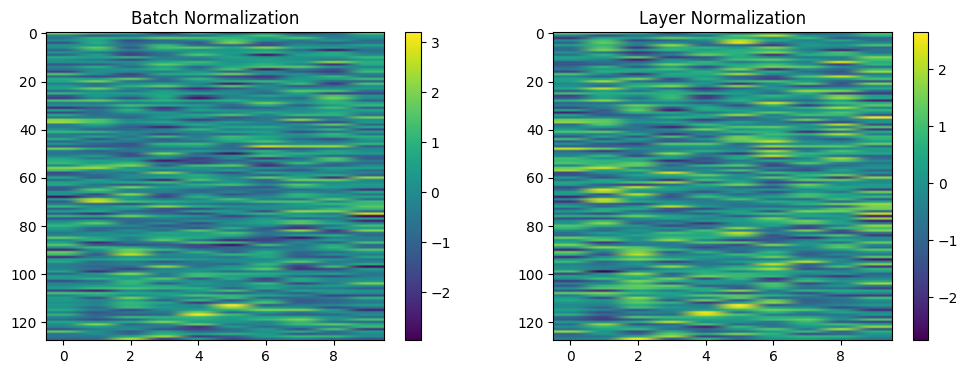

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)

plt.imshow(bn_output.numpy(),aspect="auto",cmap="viridis")

plt.title("Batch Normalization")

plt.colorbar()

plt.subplot(1,2,2)

plt.imshow(ln_output.numpy(),aspect="auto",cmap="viridis")

plt.title("Layer Normalization")

plt.colorbar()

plt.show()

In [11]:
print("BatchNorm Mean")

print(bn_output.mean())

print()

print("BatchNorm Variance")

print(bn_output.var())

print()

print("LayerNorm Mean")

print(ln_output.mean())

print()

print("LayerNorm Variance")

print(ln_output.var())

BatchNorm Mean
tensor(-4.8429e-09)

BatchNorm Variance
tensor(1.0008)

LayerNorm Mean
tensor(-1.4901e-09)

LayerNorm Variance
tensor(1.0008)
